In [2]:
# Load dependencies
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

from create_split import create_split
from plot_fitness_landscape import visualize_fitness_landscape

In [16]:
# Load dataset
df = pd.read_csv('../tf_bind_8-SIX6_REF_R1/dataset.csv')
df['split'] = ['None'] * len(df)

print("Dataset loaded with shape:", df.shape)

df.head()

Dataset loaded with shape: (65792, 11)


,0,1,2,3,4,5,6,7,sequence,binding_scores,split
0,0,0,0,0,0,0,0,0,AAAAAAAA,0.524749,None
1,0,0,0,0,0,0,0,1,AAAAAAAC,0.366511,None
2,0,0,0,0,0,0,0,2,AAAAAAAG,0.446759,None
3,0,0,0,0,0,0,0,3,AAAAAAAT,0.455201,None
4,0,0,0,0,0,0,1,0,AAAAAACA,0.512627,None


In [17]:
df = create_split(df, k_seeds=50, n_training_seeds=20, random_state=42)
df.head()


,0,1,2,3,4,5,6,7,sequence,binding_scores,split,cluster,distance_to_seed
0,0,0,0,0,0,0,0,0,AAAAAAAA,0.524749,test_a,30,3
1,0,0,0,0,0,0,0,1,AAAAAAAC,0.366511,test_c,10,3
2,0,0,0,0,0,0,0,2,AAAAAAAG,0.446759,test_a,26,3
3,0,0,0,0,0,0,0,3,AAAAAAAT,0.455201,test_c,10,4
4,0,0,0,0,0,0,1,0,AAAAAACA,0.512627,test_a,30,3


In [18]:
np.unique(df.cluster.values, return_counts=True)

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
        34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49]),
 array([3169, 2557, 2604, 2670, 2707, 1777, 2298, 2004, 1630, 1648, 2442,
        1501, 2604, 1628, 1692, 2073, 1433, 1278, 1277, 1454, 1142, 1075,
        1051, 1129, 1220, 1099, 1056, 1220,  733,  880,  724,  610,  909,
         911,  925,  962,  743,  371,  742,  711,  850, 1103,  772,  504,
         595,  626,  854,  462,  739,  628]))

In [19]:
# list unique clusters in each split
df.groupby('split')['cluster'].unique()

split
test_a    [30, 26, 25, 19, 4, 17, 13, 3, 15, 41, 6, 39, ...
test_b    [25, 19, 26, 13, 4, 3, 6, 15, 12, 8, 45, 17, 4...
test_c    [10, 2, 22, 24, 40, 0, 28, 14, 42, 29, 35, 21,...
train     [30, 26, 19, 46, 48, 8, 12, 45, 32, 3, 39, 25,...
Name: cluster, dtype: object

split
test_c    38796
test_a    10614
train      8670
test_b     7712
Name: count, dtype: int64


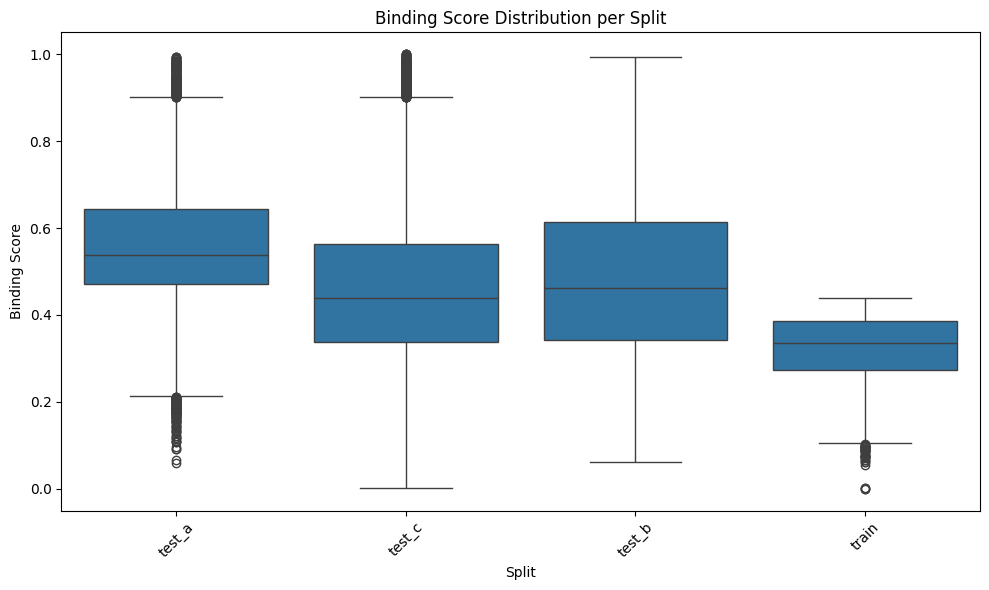

In [20]:
# Basic statistics of the splits
print(df['split'].value_counts())

# binding score distribution per split

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='split', y='binding_scores')
plt.title('Binding Score Distribution per Split')
plt.xlabel('Split')
plt.ylabel('Binding Score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Fitness Landscape Visualization

1. Dataset info: 65792 sequences
   Split distribution:
     train       :   8670 (13.18%)
     test_a      :  10614 (16.13%)
     test_b      :   7712 (11.72%)
     test_c      :  38796 (58.97%)
     unused      :      0 ( 0.00%)

2. Encoding sequences (one-hot)...
   Encoded shape: (65792, 32)

3. Loading cached 2D projection from assets/umap_n65792_seed42.pkl...
   Loaded projection shape: (65792, 2)

4. Generating plots...

   Plot 1: Fitness Landscape (Scatter)
Saved fitness landscape plot to fitness_landscape_scatter.png


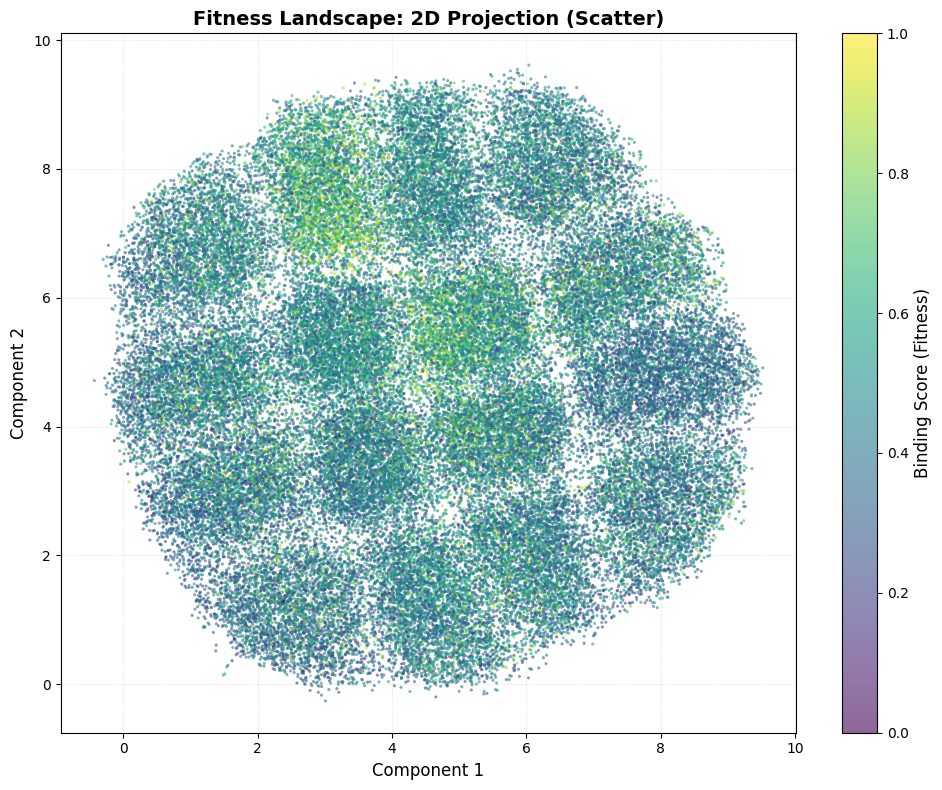


   Plot 2: Fitness Landscape (Contour)
Saved fitness landscape plot to fitness_landscape_contour.png


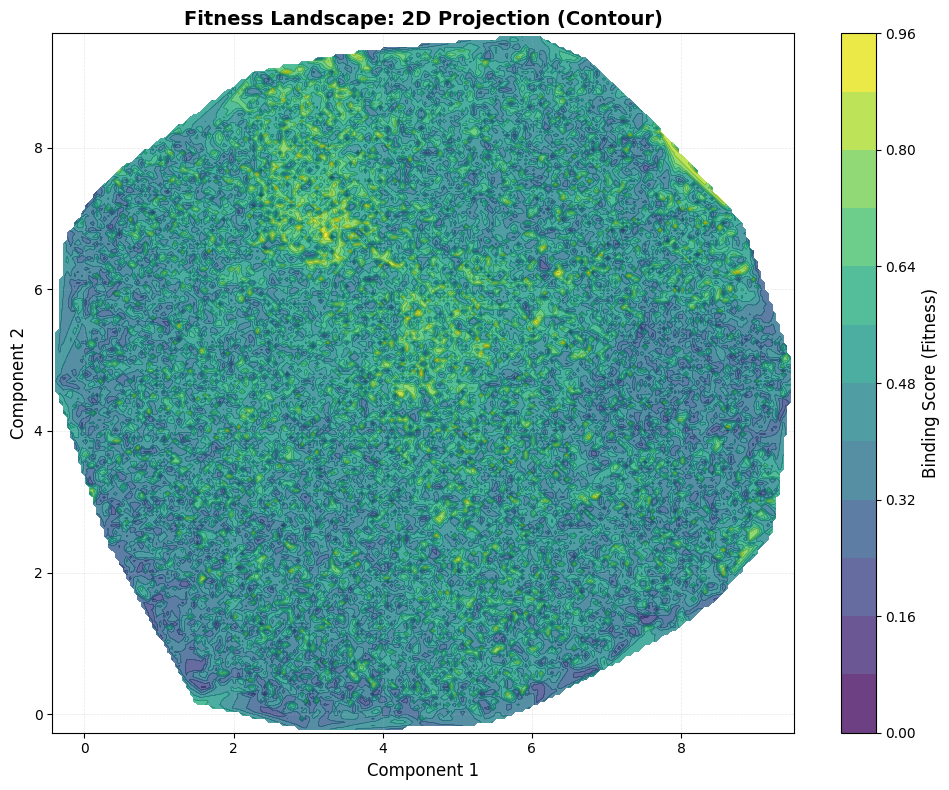


   Plot 3: Split Validation
Saved split validation plot to split_validation.png


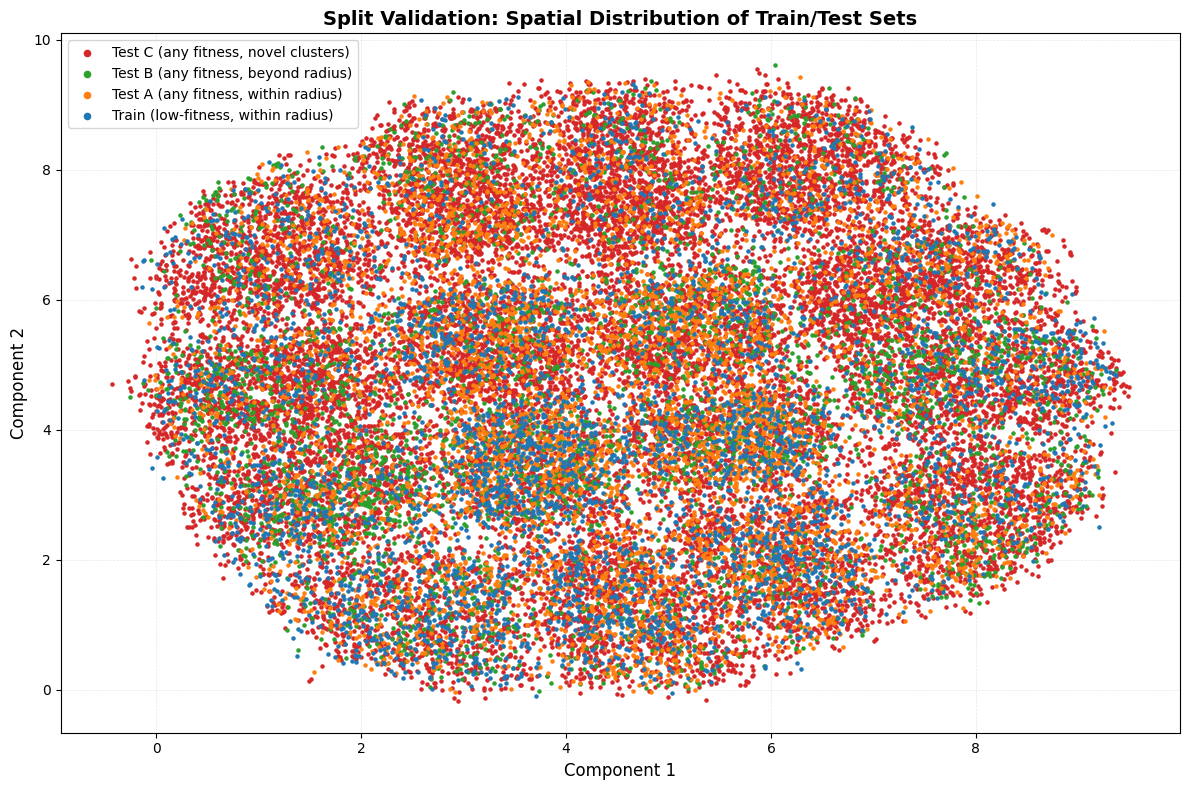


   Plot 4: Split Statistics


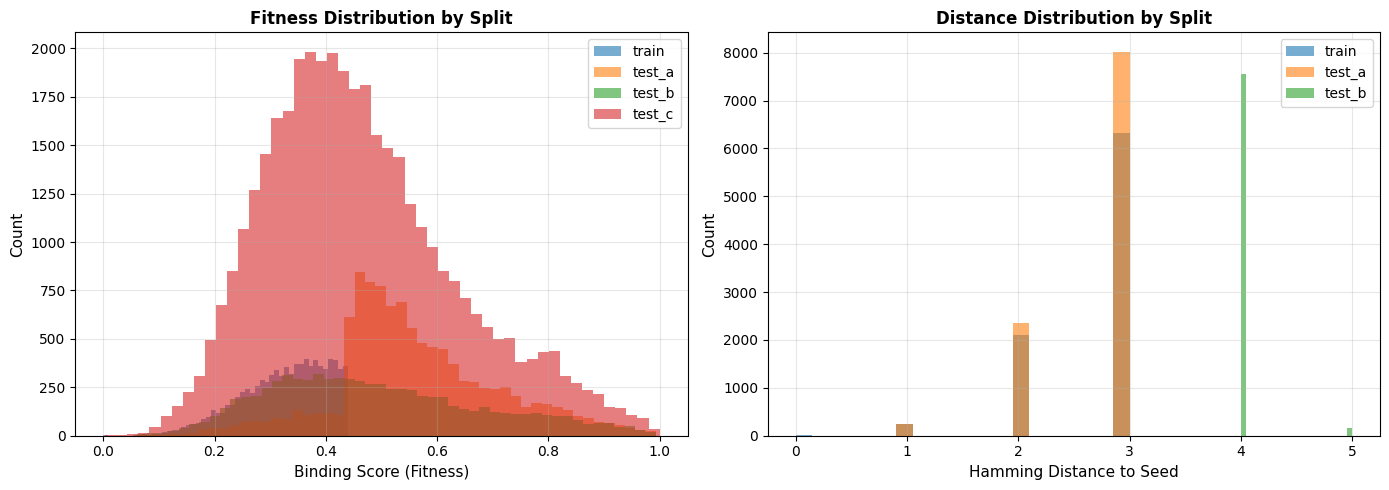


Visualization complete!


(       0  1  2  3  4  5  6  7  sequence  binding_scores   split  cluster  \
 0      0  0  0  0  0  0  0  0  AAAAAAAA        0.524749  test_a       30   
 1      0  0  0  0  0  0  0  1  AAAAAAAC        0.366511  test_c       10   
 2      0  0  0  0  0  0  0  2  AAAAAAAG        0.446759  test_a       26   
 3      0  0  0  0  0  0  0  3  AAAAAAAT        0.455201  test_c       10   
 4      0  0  0  0  0  0  1  0  AAAAAACA        0.512627  test_a       30   
 ...   .. .. .. .. .. .. .. ..       ...             ...     ...      ...   
 65787  3  3  3  2  2  0  0  0  TTTGGAAA        0.418835  test_c       20   
 65788  3  3  3  1  2  0  0  0  TTTCGAAA        0.312817  test_c       20   
 65789  3  3  3  3  1  0  0  0  TTTTCAAA        0.486455  test_c       20   
 65790  3  3  3  2  1  0  0  0  TTTGCAAA        0.449480  test_c       20   
 65791  3  3  3  3  0  0  0  0  TTTTAAAA        0.679617  test_c       20   
 
        distance_to_seed  
 0                     3  
 1                  

In [21]:
# make sure the correct embeddings are created (mind hyperparameters!!!!)
visualize_fitness_landscape(df,
                            projection_method='umap',
                            save_plots=True,
                            random_state=42)